# 02 — Geometry: How Each Parameter Shapes the Pattern

**Time: ~20 minutes.** Builds on Notebook 01.

## What you'll learn

You've integrated a calibrant frame. Now we build intuition for what
each refinable parameter physically does to the diffraction pattern:

1. **Beam centre** (`BC_y`, `BC_z`) — moves the rings around in pixel
   space.
2. **Sample-to-detector distance** (`Lsd`) — scales the rings (closer
   detector → larger rings).
3. **Wavelength** (`λ`) — shifts the rings by Bragg's law.
4. **Tilts** (`ty`, `tz`) — make the rings *elliptical* (which is what
   you saw in notebook 01!) and break the η-uniformity that
   :class:`EtaUniformityLoss` exploits in notebook 03.
5. **Distortion** (`iso_R2`, `iso_R4`, …) — spatial-dependent radial
   shifts; mostly a ~0.1 px effect for high-quality detectors.

By the end you will know **what to look at** in an integrated pattern
to diagnose which parameter is wrong, which is the prerequisite for
calibration refinement (notebook 03).


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from copy import deepcopy

HERE = Path.cwd() if Path.cwd().name == "notebooks" else Path("notebooks")
REPO = HERE.resolve().parents[2]
DATA = REPO / "FF_HEDM" / "Example" / "Calibration"

from midas_integrate_v2 import (
    spec_from_v1_paramstest,
    SubpixelBinGeometry, integrate_subpixel,
)


def make_synthetic_image(spec, *, ring_d_A=(3.124, 2.706, 1.913, 1.633),
                          peak_width_px=1.0):
    """Forward-simulate a noiseless multi-ring image with the spec's
    geometry. We use this so you can perturb a parameter and see the
    pattern change without re-loading real data."""
    NY, NZ = spec.NrPixelsY, spec.NrPixelsZ
    BC_y = float(spec.BC_y); BC_z = float(spec.BC_z)
    px = spec.pxY
    Lsd = float(spec.Lsd)
    lam = float(spec.Wavelength)

    yy, zz = np.meshgrid(np.arange(NY), np.arange(NZ), indexing="xy")
    Yc = -(yy - BC_y) * px
    Zc = (zz - BC_z) * px
    R_um = np.sqrt(Yc * Yc + Zc * Zc)
    img = np.zeros((NZ, NY), dtype=np.float64)
    for d in ring_d_A:
        two_theta = 2.0 * np.arcsin(lam / (2.0 * d))
        R0_px = (Lsd / px) * np.tan(two_theta)
        R_px = R_um / px
        img += np.exp(-((R_px - R0_px) ** 2) / (2 * peak_width_px ** 2))
    return img


def integrate_to_2d(spec, image):
    """Convenience: 1-line integrate to (n_eta, n_r)."""
    geom = SubpixelBinGeometry.from_spec(spec, K=2)
    img_t = torch.from_numpy(image)
    return integrate_subpixel(img_t, geom, normalize=True).numpy()


def to_1d(int2d):
    return int2d.mean(axis=0)


def r_axis(spec):
    n_r = spec.n_r_bins
    return spec.RMin + spec.RBinSize * (np.arange(n_r) + 0.5)


# Shared spec — load Pilatus calibration as starting point.
spec0 = spec_from_v1_paramstest(DATA / "parameters.txt", requires_grad=False)
spec0.RBinSize = 2.0
spec0.EtaBinSize = 5.0
spec0.NrPixelsY = 256       # downsample for speed in this notebook
spec0.NrPixelsZ = 256
spec0.BC_y = torch.tensor(128.0 + 0.37, dtype=torch.float64)
spec0.BC_z = torch.tensor(128.0 - 0.41, dtype=torch.float64)
spec0.Lsd  = torch.tensor(657_437.0, dtype=torch.float64)

print(f"Using a downsampled 256×256 detector for speed; "
      f"physics is unchanged.")
print(f"Lsd = {float(spec0.Lsd) / 1000:.1f} mm, "
      f"λ = {float(spec0.Wavelength):.6f} Å")

img0 = make_synthetic_image(spec0)
int2d_0 = integrate_to_2d(spec0, img0)
prof0 = to_1d(int2d_0)

# Identify which R bins have the rings (for plotting visual reference)
ring_indices = np.where(prof0 > 0.05 * prof0.max())[0]


Using a downsampled 256×256 detector for speed; physics is unchanged.
Lsd = 657.4 mm, λ = 0.172973 Å


## Beam centre — moves the rings around

If your `BC` is wrong by 1 px in Y or Z, the integrated 1-D profile
will look *almost* unchanged (peak intensities very slightly different)
but the 2-D `(n_eta, n_r)` integrated array shows a clear non-uniformity
along η: the same ring lands at slightly different R for different η.

This non-uniformity is the calibration signal — it's what
`EtaUniformityLoss` minimises in notebook 03.


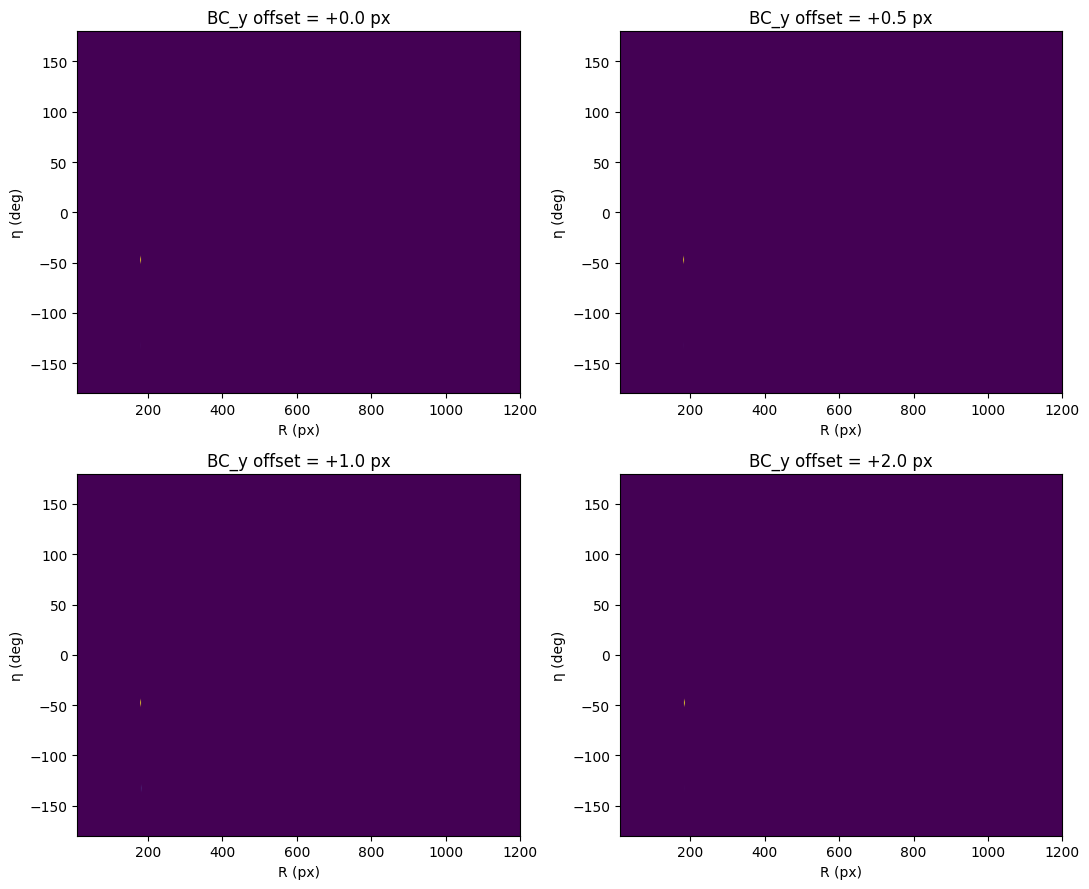

In [2]:
def perturbed_spec(base, **kwargs):
    s = spec_from_v1_paramstest(DATA / "parameters.txt", requires_grad=False)
    s.RBinSize = base.RBinSize
    s.EtaBinSize = base.EtaBinSize
    s.NrPixelsY = base.NrPixelsY
    s.NrPixelsZ = base.NrPixelsZ
    for f in ("Lsd","BC_y","BC_z","tx","ty","tz","Parallax","Wavelength",
              "iso_R2","iso_R4","iso_R6"):
        setattr(s, f, getattr(base, f).clone() if hasattr(getattr(base, f), 'clone') else getattr(base, f))
    for k, v in kwargs.items():
        setattr(s, k, torch.tensor(v, dtype=torch.float64) if not isinstance(v, torch.Tensor) else v)
    return s


fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, dy in zip(axes.flat, [0.0, 0.5, 1.0, 2.0]):
    s = perturbed_spec(spec0, BC_y=float(spec0.BC_y) + dy)
    int2d = integrate_to_2d(s, img0)
    im = ax.imshow(int2d, aspect="auto", cmap="viridis", origin="lower",
                   extent=[s.RMin, s.RMax, s.EtaMin, s.EtaMax])
    ax.set_title(f"BC_y offset = +{dy} px")
    ax.set_xlabel("R (px)"); ax.set_ylabel("η (deg)")
plt.tight_layout()
plt.show()


**What you should see:** at `dy=0` (true BC) every ring is a perfectly
straight horizontal line — the same R at every η. At `dy=2 px` the
rings curve into sinusoidal shapes — same ring lands at *different*
R depending on η. That curvature is the BC signal.

**Try it:** change which ring gets perturbed by changing
`spec0.RMin` or zooming `set_xlim`. The first ring (small R) is
*more* sensitive to BC than the outer rings.

## Sample-to-detector distance — scales the rings

Lsd controls the overall ring radii: `R = (Lsd / px) tan(2θ)`. Halving
Lsd halves R for every ring. Unlike BC, getting Lsd wrong shifts ALL
peaks together (no η dependence) — so it's invisible in the 2-D array
but very obvious in the 1-D profile.


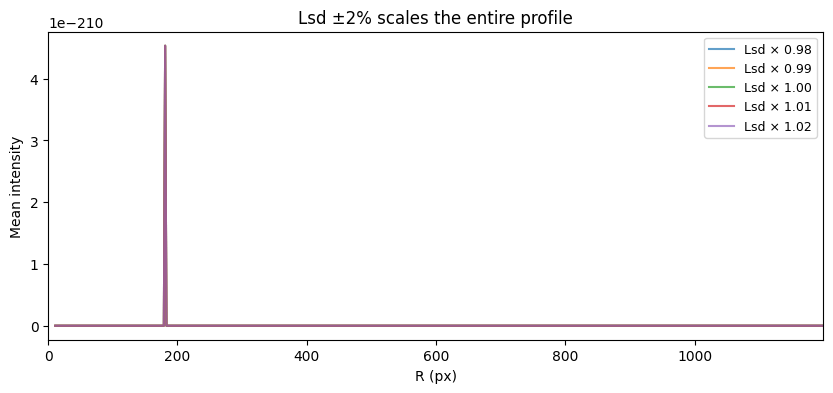

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
for delta_pct in [-2, -1, 0, +1, +2]:
    new_Lsd = float(spec0.Lsd) * (1 + delta_pct * 0.01)
    s = perturbed_spec(spec0, Lsd=new_Lsd)
    prof = to_1d(integrate_to_2d(s, img0))
    ax.plot(r_axis(s), prof, label=f"Lsd × {1 + delta_pct*0.01:.2f}",
            alpha=0.7)
ax.set_xlabel("R (px)"); ax.set_ylabel("Mean intensity")
ax.set_xlim(0, max(r_axis(spec0)))
ax.legend(loc="upper right", fontsize=9)
ax.set_title("Lsd ±2% scales the entire profile")
plt.show()


**What you should see:** five peaks for the +2% case shifted right of
the truth (longer Lsd ⇒ larger 2θ tan ⇒ larger R), -2% shifted left.
The relative spacing between peaks is preserved — Bragg's law is
linear in d at small 2θ.

**Try it:** what's the ratio R_outer / R_inner for the four rings?
Does it stay constant under Lsd change? (Answer: yes; that ratio is
a property of the lattice and the wavelength.)

## Wavelength — Bragg-law shift

Wavelength enters Bragg's law as `2θ = 2 arcsin(λ / 2d)`. Larger λ ⇒
larger 2θ ⇒ larger R. Same direction as Lsd, but a *different*
fingerprint: the ratio between rings changes (because arcsin is
nonlinear).


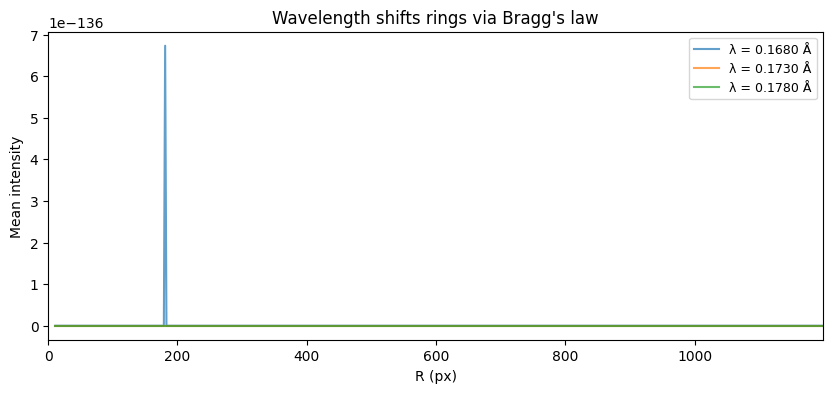

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
for delta in [-0.005, 0.0, +0.005]:
    new_lam = float(spec0.Wavelength) + delta
    s = perturbed_spec(spec0, Wavelength=new_lam)
    img = make_synthetic_image(s)         # rings depend on λ
    prof = to_1d(integrate_to_2d(s, img))
    ax.plot(r_axis(s), prof, label=f"λ = {new_lam:.4f} Å", alpha=0.7)
ax.set_xlabel("R (px)"); ax.set_ylabel("Mean intensity")
ax.set_xlim(0, max(r_axis(spec0)))
ax.legend(loc="upper right", fontsize=9)
ax.set_title("Wavelength shifts rings via Bragg's law")
plt.show()


**Key practical fact**: with a single calibrant ring, you cannot
distinguish "wavelength is wrong" from "Lsd is wrong" — they both
shift R the same way. Multi-ring or multi-distance calibration breaks
this degeneracy. (Notebook 04 covers multi-distance.)

## Tilts — ellipticity in the rings

Tilting the detector by even ~0.5° away from perpendicular to the beam
makes the rings *elliptical*: shorter R at one η than at the opposite
η. This is what your real Pilatus pattern in notebook 01 was actually
showing (the calibrated `ty=0.20°, tz=0.45°` tilts).


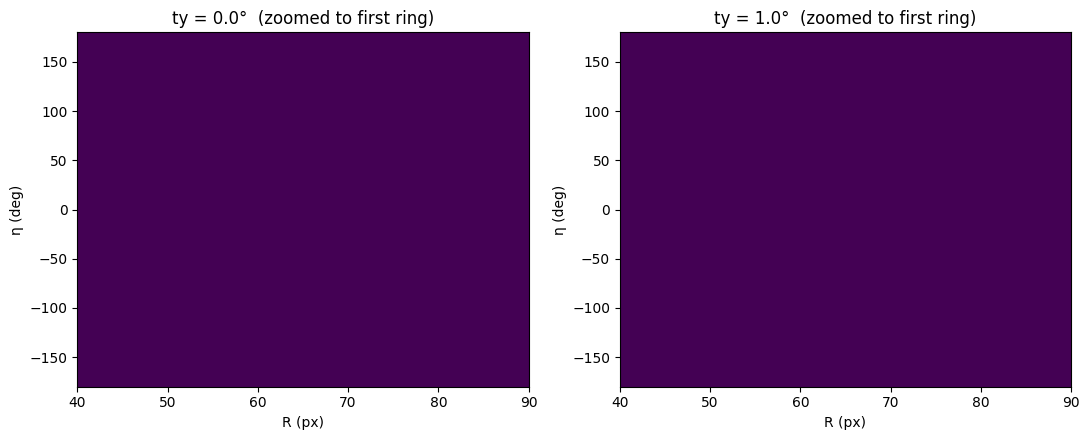

In [5]:
# A pristine no-tilt geometry vs a 1° tilt for visualization
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, ty in zip(axes, [0.0, 1.0]):
    s = perturbed_spec(spec0, ty=ty, tz=0.0)
    img = make_synthetic_image(s)
    int2d = integrate_to_2d(s, img)
    im = ax.imshow(int2d, aspect="auto", cmap="viridis", origin="lower",
                   extent=[s.RMin, s.RMax, s.EtaMin, s.EtaMax])
    ax.set_title(f"ty = {ty:.1f}°  (zoomed to first ring)")
    ax.set_xlim(40, 90)
    ax.set_xlabel("R (px)"); ax.set_ylabel("η (deg)")
plt.tight_layout()
plt.show()


**Tilts produce a sinusoidal η-dependence of R**: at ty=1°, the ring
sweeps roughly ±1 px across the full 360° of η. Larger tilts ⇒ larger
sinusoidal amplitude.

**This is exactly the η-uniformity signal that drives calibration
refinement** in notebook 03. When the geometry is right, every ring
is a flat horizontal line in the 2-D plot.

## Putting it together

| Symptom in the 2-D `(η, R)` plot | Probable parameter |
|---|---|
| Rings flat in η, all peaks shifted | Lsd or wavelength |
| Rings curve as sin(η) | BC offset |
| Rings curve as sin(2η) | Tilt |
| Rings flat but only inner ones shifted | Distortion (rare) |

**This intuition is the foundation of calibration.** Notebook 03
turns it into a refinement loop that automates the whole thing.

## Recap

- BC controls ring centre (sin(η)-pattern).
- Lsd and λ scale the rings (no η dependence).
- Tilts produce sin(2η)-pattern.
- Distortion makes ring positions slightly r-dependent.

## Next: 03 — Refining Calibration with Joint Optimization

You'll write a refinement loop that reads a calibrant frame, perturbs
BC by 1 px, and uses gradient descent on `EtaUniformityLoss` to put
it back. That's the v2 headline workflow — and it works on real
Pilatus data (you'll see).
